In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from scipy.stats import chi2
from sklearn.preprocessing import LabelEncoder
import re
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from adjustText import adjust_text


# Color mapping (hex codes)
colors = {
    'Cardiac precursor': "#a086bd", 
    'Cardiomyocyte': "#6b4e71",
    'ESC': '#6bcfcf',
    'ESC-derived NPC': '#d4adab', 
    'ESC-derived neurons': '#469433',
    'Fetal NPC': '#967978',
    'Fetal neurons': '#a85858',
    'Heart tissue': "#5f1ea6",
    'Mesodermal cells': "#6bcfcf",
    'NES': '#e8bc64',
    'NPC': '#e38519',
    'NSC': '#e38519',
    'Post-mortem neurons': '#034e91',
    'Adult neurons': '#034e91',
    'Post-mortem non-neurons': '#a87963',
    'iPSC': '#696969',
    'iPSC-derived cardiac mesoderm': "#bfb2cf",  
    'iPSC-derived cardiac precursor': "#a086bd",
    'iPSC-derived cardiomyocyte': "#9955a2",
    'iPSC-derived glia': '#a87963',
    'iPSC-derived neurons': '#469433',
    'iPSC-derived neurons_short': '#b0e8a9',
    'iPSC-derived neurons_medium': '#1fc24a',
    'iPSC-derived neurons_long': '#08472b',
    'Primary fetal neurons': '#a85858',
    "Primary neurons": '#469433'
}

green_shades = {
    'short': '#a1d99b',   # light green
    'medium': '#41ab5d',  # medium green
    'long': '#005a32'     # dark green
}

# Shape mapping (matplotlib marker codes)
shapes = {
    'Fetal neurons': 'o',         # 16 in R = 'o' (circle)
    'Fetal NPC': '^',             # 18 in R = '^' (triangle_up)
    'iPSC-derived neurons': 'o',
    'iPSC-derived neurons_short': 'o',
    'iPSC-derived neurons_medium': 'o',
    'iPSC-derived neurons_long': 'o',
    'iPSC': 'o',
    'NPC': 'o',
    'NSC': '^',
    "NES": 'o',
    "ESC": 'o',
    'ESC-derived NPC': 'o',
    'ESC-derived neurons': '^',
    'Post-mortem neurons': 'o',
    'Post-mortem non-neurons': 'o',
    'Adult neurons': 'o',
    'iPSC-derived glia': 'o',
    'ES-derived neurons': '^',
    'Heart tissue': 'o',
    'iPSC-derived cardiac mesoderm': 'o',
    'iPSC-derived cardiac precursor': 'o',
    'iPSC-derived cardiomyocyte': 'o',
    'Cardiomyocyte': 'v',         # 17 in R = 'v' (triangle_down)
    'Cardiac precursor': 'D',     # 25 in R = 'D' (diamond)
    'Mesodermal cells': '^',
    "Fetal heart tissue": 'v',
    "Primary neurons": 'v',
    'Primary fetal neurons': 'v'
}

# Size mapping (matplotlib s parameter, scale as needed)
sizes = {
    'Fetal neurons': 60,
    'Fetal ES-derived neurons': 60,
    'Fetal NPC': 60,
    'Fetal stem-like cells': 60,
    'iPSC-derived neurons': 60,
     'iPSC-derived neurons_short': 60,
    'iPSC-derived neurons_medium': 60,
    'iPSC-derived neurons_long': 60,
    'ESC-derived NPC': 60,
    'ESC-derived neurons': 60,
    'iPSC': 60,
    'Adult neurons': 60,
    'NPC': 60,
    'NSC': 60,
    "NES": 60,
    "ESC": 60,
    'Post-mortem neurons': 60,
    'Post-mortem non-neurons': 60,
    'iPSC-derived glia': 60,
    'ES-derived neurons': 60,
    'Heart tissue': 60,
    'iPSC-derived cardiac mesoderm': 60,
    'iPSC-derived cardiac precursor': 60,
    'iPSC-derived cardiomyocyte': 60,
    'Cardiomyocyte': 60,
    'Cardiac precursor': 60,
    'Mesodermal cells': 60,
    "Fetal heart tissue": 60,
    "Primary neurons": 60,
    'Primary fetal neurons': 60
}

# Define protocol shapes for iPSC-derived neurons
protocol_shapes = {
    'Arima-HiC (in situ)': 'o',  # circle
    'eHi-C': 's',                # square
    'In situ Hi-C': '^',         # triangle
}
green_shades = {
    'short': '#a1d99b',   # light green
    'medium': '#41ab5d',  # medium green
    'long': '#005a32'     # dark green
}

DATA_PATH = './data_files/insulation_pca_data_human.tsv'
METADATA_PATH = "./data_files/ipsc_derived_neurons_humans_metadata.csv"
METADATA_PATH_POST_MORTEM = "./data_files/post_mortem_neurons_humans_metadata.csv"


Saved → ./pca_duration_continuous.pdf
Saved → ./pca_duration_continuous.svg


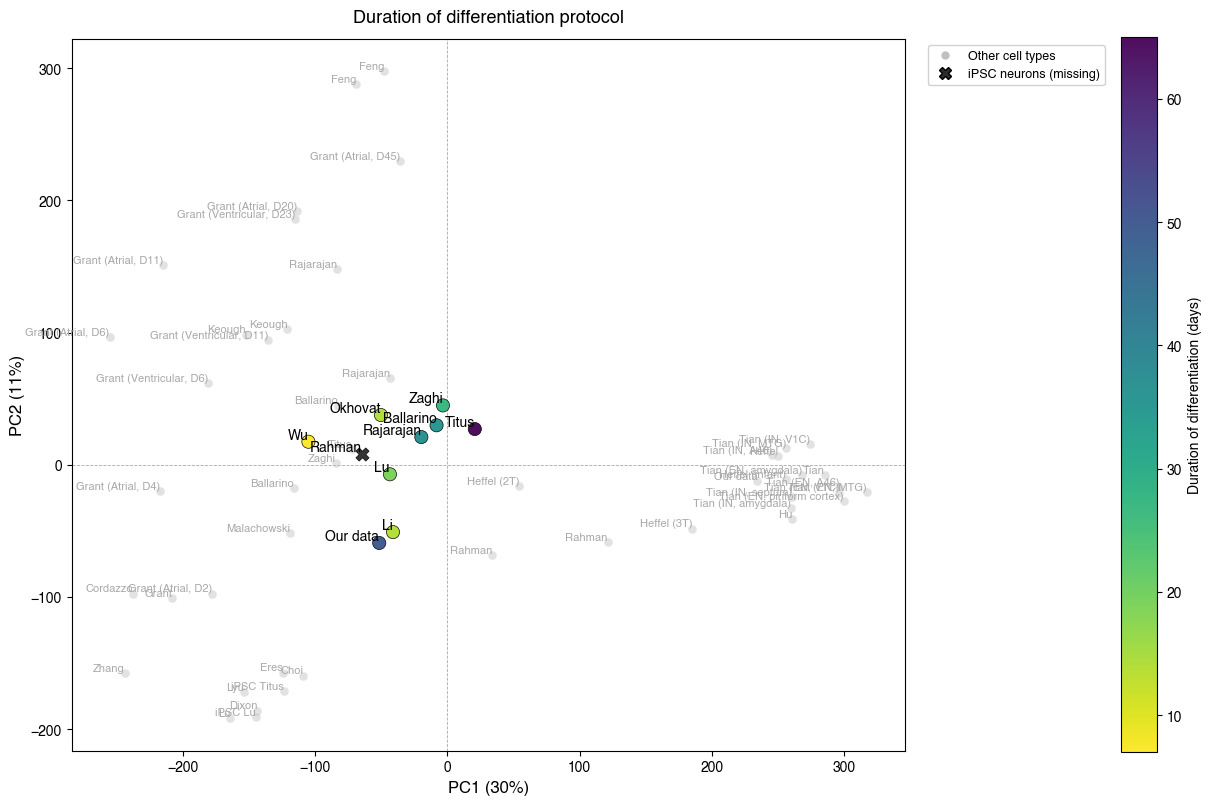

Saved → ./pca_protocol_label.pdf
Saved → ./pca_protocol_label.svg


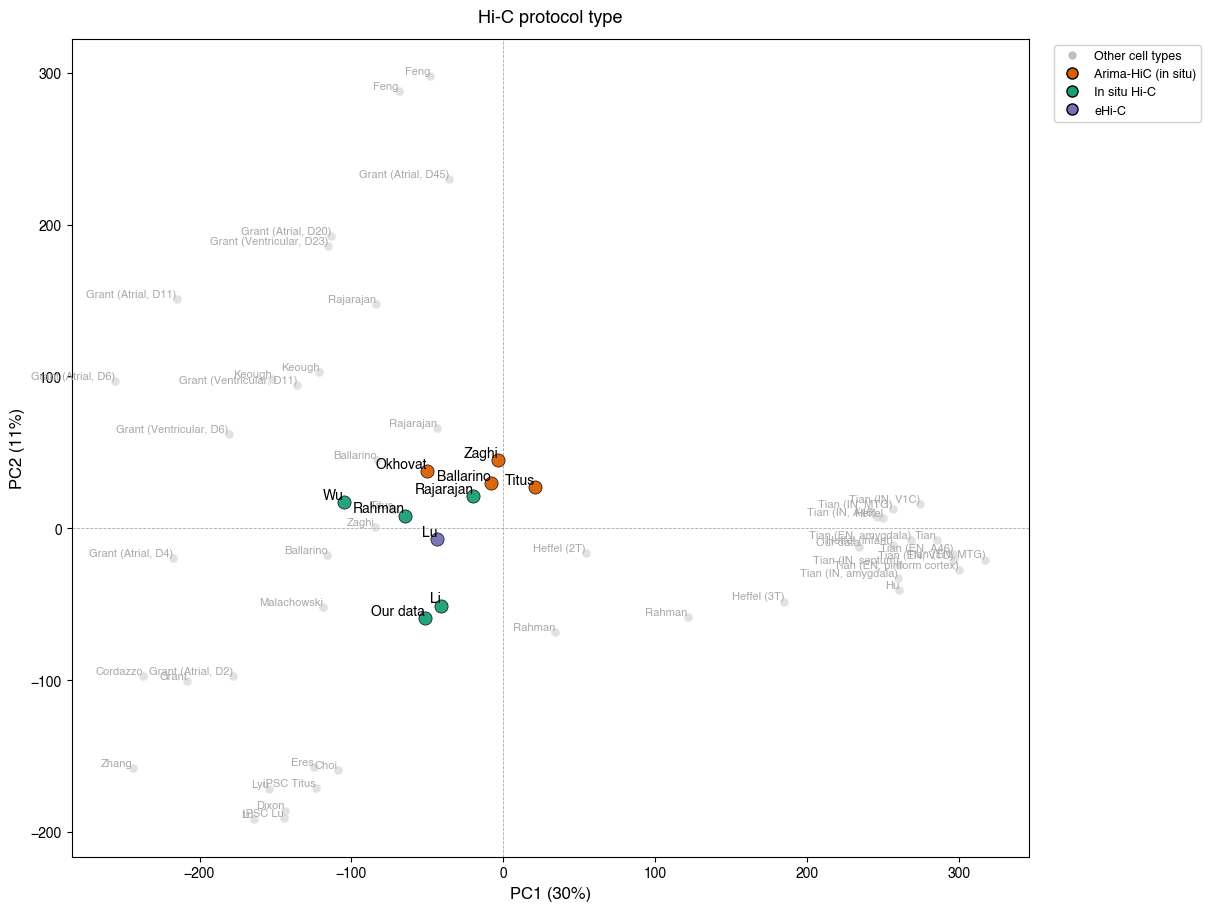

Saved → ./pca_restriction_enzyme.pdf
Saved → ./pca_restriction_enzyme.svg


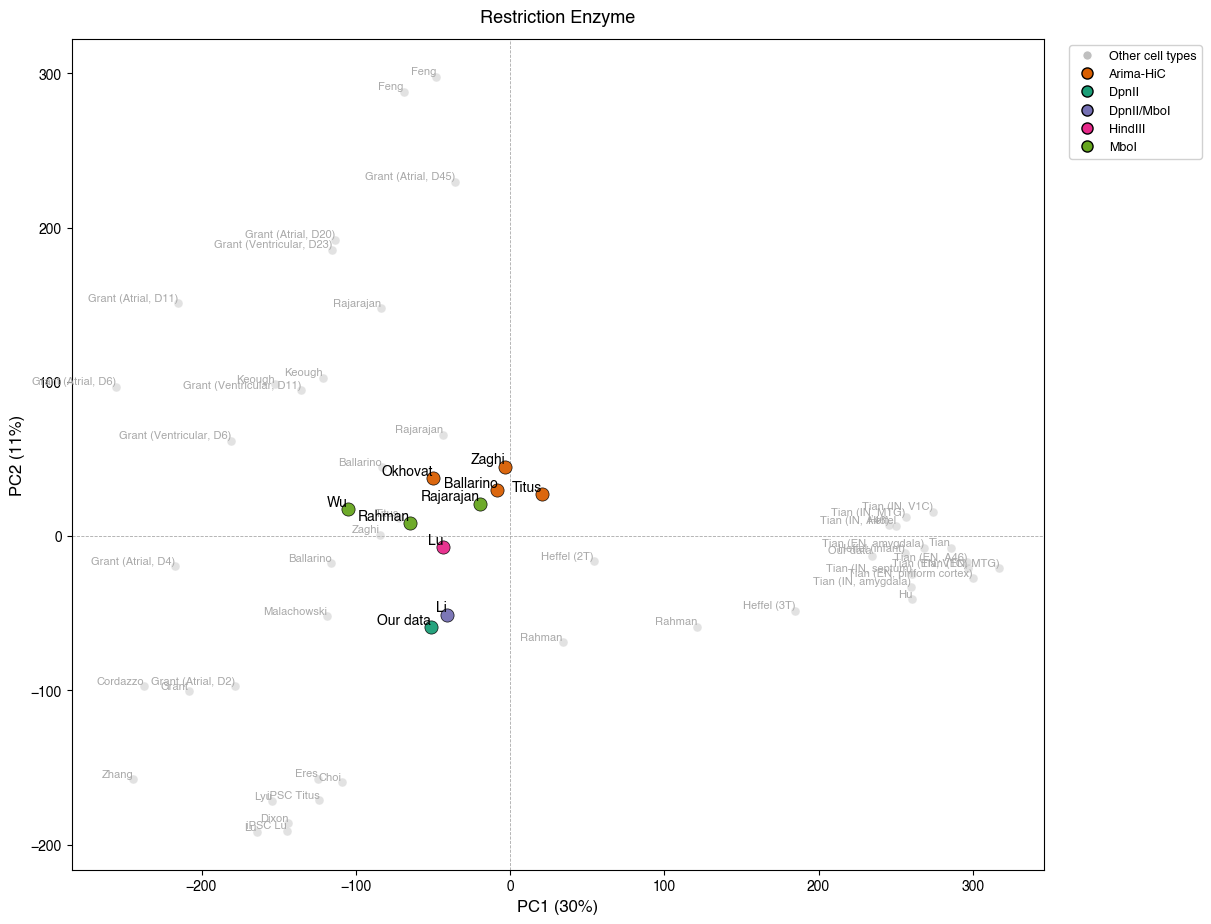

Saved → ./pca_combined_properties.pdf
Saved → ./pca_combined_properties.svg


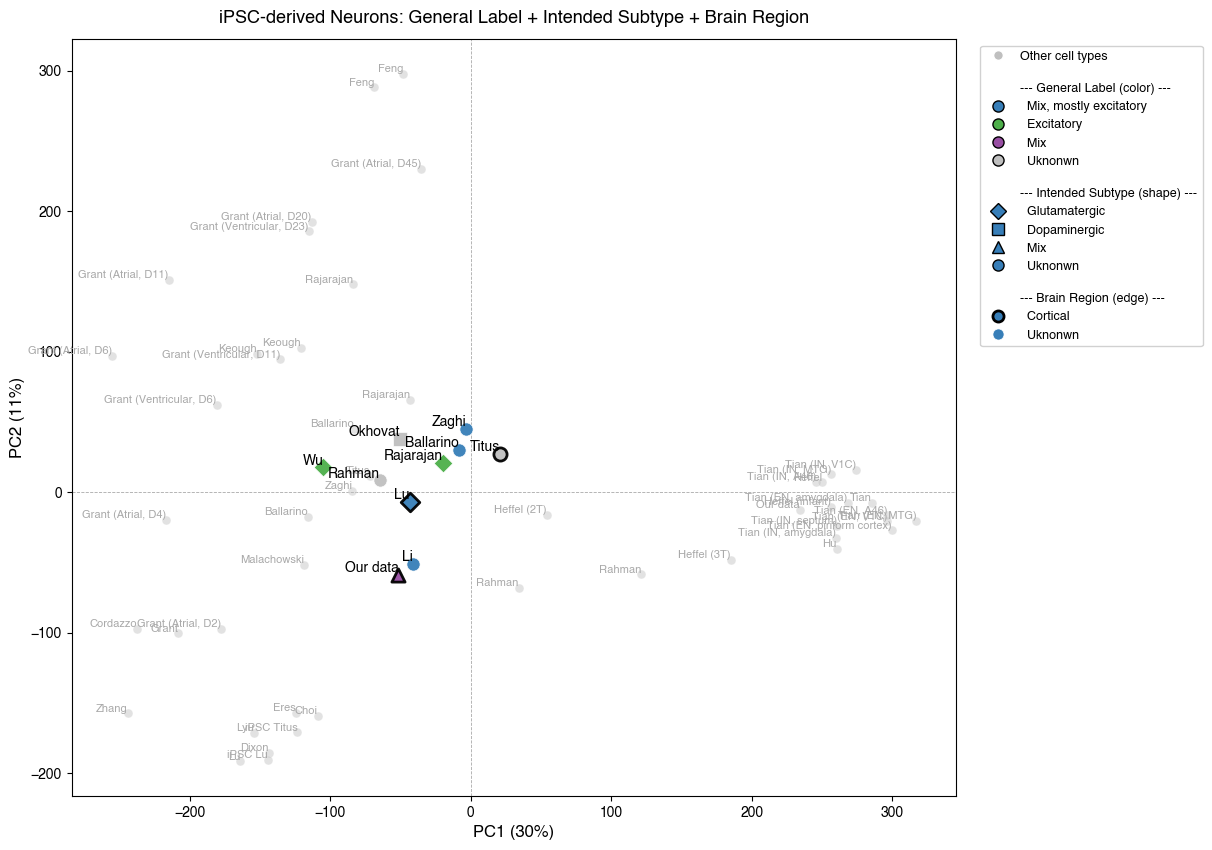

In [72]:
# Set SVG font type to none for editable text in SVG files
plt.rcParams["svg.fonttype"] = "none"

# Set font to Helvetica for consistent styling
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
plt.rcParams["pdf.fonttype"] = 42  # TrueType fonts in PDF

OUTPUT_DIR = "."  # change to desired output folder

PC1_VAR = 30  # % variance explained
PC2_VAR = 11

GREY = "#bfbfbf"
MISSING_COLOR = "#2b2b2b"  # dark charcoal for missing metadata
HIGHLIGHT_GROUP = "iPSC-derived neurons"

# Categorical palettes – scientific, colorblind-friendly (adapted from ColorBrewer)
PROTOCOL_PALETTE = {
    "Arima-HiC (in situ)": "#d95f02",  # orange
    "eHi-C":              "#7570b3",  # muted purple
    "In situ Hi-C":       "#1b9e77",  # teal
}

ENZYME_PALETTE = {
    "Arima-HiC":  "#d95f02",  # orange
    "DpnII":      "#1b9e77",  # teal
    "DpnII/MboI": "#7570b3",  # muted purple
    "HindIII":    "#e7298a",  # magenta-pink
    "MboI":       "#66a61e",  # olive green
}

# Combined 3-property visualization palettes
# General label palette (4 colors - primary distinction)
GENERAL_LABEL_PALETTE = {
    "Mix, mostly excitatory": "#377eb8",  # blue
    "Excitatory": "#4daf4a",  # green
    "Mix": "#984ea3",  # purple
    "Uknonwn": "#bfbfbf",  # grey
}

# Intended subtypes - represented by marker shape
SUBTYPE_MARKERS = {
    "Glutamatergic": "D",  # circle
    "Dopaminergic": "s",  # square
    "Mix": "^",  # triangle
    "Uknonwn": "o",  # diamond
}

# Brain region - represented by edge style
REGION_EDGE_STYLES = {
    "Cortical": {"edgecolors": "black", "linewidths": 2.0},  # thick black edge
    "Uknonwn": {"edgecolors": "white", "linewidths": 0.5},  # thin white edge
}

FIGSIZE = (12, 12)  # Square aspect ratio
DOT_SIZE_BG = 40
DOT_SIZE_FG = 90
ALPHA_BG = 0.45
ALPHA_FG = 0.95
LABEL_FONTSIZE_BG = 8
LABEL_FONTSIZE_FG = 10


def load_data(data_path: str, metadata_path: str) -> pd.DataFrame:
    """Load PCA data and merge with iPSC-derived neuron metadata."""
    df = pd.read_csv(data_path, sep="\t")
    df["group"] = df["Group"]
    df["PC1"] = pd.to_numeric(df["PC1"], errors="coerce")
    df["PC2"] = pd.to_numeric(df["PC2"], errors="coerce")
    if "sample_simple" not in df.columns:
        df["sample_simple"] = df["Sample"]

    # Build merge key
    df["author"] = df["sample_simple"].apply(lambda x: str(x).split(" ")[0])
    df["ID"] = df["author"] + "_" + df["Group"]

    # Metadata
    meta = pd.read_csv(metadata_path)
    meta["author"] = meta["sample_simple"].apply(lambda x: str(x).split(" ")[0])
    meta["ID"] = meta["author"] + "_" + meta["Celltype"]
    meta = meta[
        [
            "Hi-C protocol",
            "Celltype",
            "Duration of differentiation (days)",
            "Protocol label",
            "Restriction Enzyme",
            "Intended subtypes",
            "General label",
            "Brain region",
            "ID",
        ]
    ]
    df = df.merge(meta, on="ID", how="left")

    # Strip whitespace from metadata string columns
    for col in ["Protocol label", "Restriction Enzyme", "Intended subtypes", "General label", "Brain region"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace({"nan": np.nan, "": np.nan})

    # Numeric duration
    def _extract_number(s):
        if pd.isna(s):
            return np.nan
        m = re.search(r"\d+", str(s))
        return float(m.group()) if m else np.nan

    df["duration_days"] = df["Duration of differentiation (days)"].apply(
        _extract_number
    )
    return df


# ──────────────────────────────────────────────────────────────────────────────
# 3. PLOTTING HELPERS
# ──────────────────────────────────────────────────────────────────────────────


def _add_labels(ax, df_subset, fontsize, color="dimgrey"):
    """Add sample_simple text labels and return the Text objects."""
    texts = []
    for _, row in df_subset.iterrows():
        t = ax.text(
            row["PC1"], row["PC2"],
            str(row["sample_simple"]),
            fontsize=fontsize,
            color=color,
            ha="right", va="bottom",
            zorder=5,
        )
        texts.append(t)
    return texts


def _base_ax(df: pd.DataFrame) -> tuple:
    """Create figure, plot grey background dots with labels, return (fig, ax, bg_texts)."""
    fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

    bg = df[df["group"] != HIGHLIGHT_GROUP]
    ax.scatter(
        bg["PC1"],
        bg["PC2"],
        c=GREY,
        s=DOT_SIZE_BG,
        alpha=ALPHA_BG,
        edgecolors="white",
        linewidths=0.3,
        zorder=1,
        label="_nolegend_",
    )

    bg_texts = _add_labels(ax, bg, LABEL_FONTSIZE_BG, color="#aaaaaa")

    ax.axhline(0, color="darkgrey", ls="--", lw=0.6, zorder=0)
    ax.axvline(0, color="darkgrey", ls="--", lw=0.6, zorder=0)
    ax.set_xlabel(f"PC1 ({PC1_VAR}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({PC2_VAR}%)", fontsize=12)
    ax.tick_params(labelsize=10)
    ax.set_aspect('equal', adjustable='box')  # Make plot area square
    return fig, ax, bg_texts


def _finish(fig, ax, title: str, fname: str, legend_handles=None, all_texts=None):
    """Add title, legend, adjust labels, save and show."""
    ax.set_title(title, fontsize=13, pad=12)
    if legend_handles is not None:
        ax.legend(
            handles=legend_handles,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            fontsize=9,
            frameon=True,
            framealpha=0.9,
            title_fontsize=10,
        )
    # Save both PDF and SVG formats
    base_name = fname.rsplit(".", 1)[0]  # Remove extension
    pdf_out = f"{OUTPUT_DIR}/{base_name}.pdf"
    svg_out = f"{OUTPUT_DIR}/{base_name}.svg"
    
    # Don't use bbox_inches='tight' as it can distort the square aspect ratio
    fig.savefig(pdf_out, dpi=300)
    fig.savefig(svg_out)
    
    print(f"Saved → {pdf_out}")
    print(f"Saved → {svg_out}")
    plt.show()


def _get_palette(series: pd.Series, predefined: dict) -> dict:
    """Return a palette dict covering every unique non-null value in *series*.

    Uses *predefined* colours where available; assigns new colours from tab10
    for any unseen categories.
    """
    unique_vals = sorted(series.dropna().unique(), key=str)
    palette = {}
    extra_idx = 0
    extra_colors = plt.cm.tab10.colors
    for v in unique_vals:
        if v in predefined:
            palette[v] = predefined[v]
        else:
            palette[v] = mcolors.to_hex(extra_colors[extra_idx % len(extra_colors)])
            extra_idx += 1
    return palette


# ──────────────────────────────────────────────────────────────────────────────
# 4. FIGURE FUNCTIONS
# ──────────────────────────────────────────────────────────────────────────────


def plot_duration(df: pd.DataFrame):
    """Fig 1 – iPSC-derived neurons coloured by duration (continuous)."""
    fig, ax, bg_texts = _base_ax(df)
    fg = df[df["group"] == HIGHLIGHT_GROUP].copy()

    has_val = fg["duration_days"].notna()
    fg_miss = fg[~has_val]
    fg_good = fg[has_val]

    # Missing
    if not fg_miss.empty:
        ax.scatter(
            fg_miss["PC1"],
            fg_miss["PC2"],
            c=MISSING_COLOR,
            s=DOT_SIZE_FG,
            alpha=ALPHA_FG,
            edgecolors="k",
            linewidths=0.5,
            zorder=3,
            marker="X",
        )

    # Continuous colormap (reversed: lighter = fewer days, darker = more days)
    if not fg_good.empty:
        vmin = fg_good["duration_days"].min()
        vmax = fg_good["duration_days"].max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.viridis_r  # reversed: light (yellow) = short, dark (purple) = long
        sc = ax.scatter(
            fg_good["PC1"],
            fg_good["PC2"],
            c=fg_good["duration_days"],
            cmap=cmap,
            norm=norm,
            s=DOT_SIZE_FG,
            alpha=ALPHA_FG,
            edgecolors="k",
            linewidths=0.5,
            zorder=3,
        )
        cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
        cbar.set_label("Duration of differentiation (days)", fontsize=10)

    # Foreground labels
    fg_texts = _add_labels(ax, fg, LABEL_FONTSIZE_FG, color="black")

    # Legend for missing
    handles = []
    handles.append(
        Line2D([0], [0], marker="o", color="w", markerfacecolor=GREY,
               markersize=7, label="Other cell types", markeredgecolor="white")
    )
    if not fg_miss.empty:
        handles.append(
            Line2D([0], [0], marker="X", color="w", markerfacecolor=MISSING_COLOR,
                   markersize=8, label="iPSC neurons (missing)", markeredgecolor="k")
        )
    _finish(fig, ax, "Duration of differentiation protocol",
            "pca_duration_continuous.pdf", handles, all_texts=bg_texts + fg_texts)


def plot_categorical(
    df: pd.DataFrame,
    col: str,
    predefined_palette: dict,
    title: str,
    fname: str,
):
    """Generic categorical colouring for iPSC-derived neurons."""
    fig, ax, bg_texts = _base_ax(df)
    fg = df[df["group"] == HIGHLIGHT_GROUP].copy()

    palette = _get_palette(fg[col], predefined_palette)

    has_val = fg[col].notna()
    fg_miss = fg[~has_val]
    fg_good = fg[has_val]

    # Plot each category
    for cat, colour in palette.items():
        sub = fg_good[fg_good[col] == cat]
        if sub.empty:
            continue
        ax.scatter(
            sub["PC1"],
            sub["PC2"],
            c=colour,
            s=DOT_SIZE_FG,
            alpha=ALPHA_FG,
            edgecolors="k",
            linewidths=0.5,
            zorder=3,
        )

    # Missing
    if not fg_miss.empty:
        ax.scatter(
            fg_miss["PC1"],
            fg_miss["PC2"],
            c=MISSING_COLOR,
            s=DOT_SIZE_FG,
            alpha=ALPHA_FG,
            edgecolors="k",
            linewidths=0.5,
            zorder=3,
            marker="X",
        )

    # Foreground labels
    fg_texts = _add_labels(ax, fg, LABEL_FONTSIZE_FG, color="black")

    # Legend
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=GREY,
               markersize=7, label="Other cell types", markeredgecolor="white")
    ]
    for cat, colour in palette.items():
        handles.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor=colour,
                   markersize=8, label=str(cat), markeredgecolor="k")
        )
    if not fg_miss.empty:
        handles.append(
            Line2D([0], [0], marker="X", color="w", markerfacecolor=MISSING_COLOR,
                   markersize=8, label="Missing", markeredgecolor="k")
        )
    _finish(fig, ax, title, fname, handles, all_texts=bg_texts + fg_texts)


def plot_combined_properties(df: pd.DataFrame):
    """Fig 4 – Combined 3-property visualization."""
    fig, ax, bg_texts = _base_ax(df)
    fg = df[df["group"] == HIGHLIGHT_GROUP].copy()

    has_val = (fg["General label"].notna() &
               fg["Intended subtypes"].notna() &
               fg["Brain region"].notna())
    fg_miss = fg[~has_val]
    fg_good = fg[has_val]

    # Missing
    if not fg_miss.empty:
        ax.scatter(
            fg_miss["PC1"],
            fg_miss["PC2"],
            c=MISSING_COLOR,
            s=DOT_SIZE_FG,
            alpha=ALPHA_FG,
            edgecolors="k",
            linewidths=0.5,
            zorder=3,
            marker="X",
        )

    # Plot each category
    for label, colour in GENERAL_LABEL_PALETTE.items():
        sub = fg_good[fg_good["General label"] == label]
        if sub.empty:
            continue
        for subtype, marker in SUBTYPE_MARKERS.items():
            sub_subtype = sub[sub["Intended subtypes"] == subtype]
            if sub_subtype.empty:
                continue
            for region, edge_style in REGION_EDGE_STYLES.items():
                sub_region = sub_subtype[sub_subtype["Brain region"] == region]
                if sub_region.empty:
                    continue
                ax.scatter(
                    sub_region["PC1"],
                    sub_region["PC2"],
                    c=colour,
                    s=DOT_SIZE_FG,
                    alpha=ALPHA_FG,
                    edgecolors=edge_style["edgecolors"],
                    linewidths=edge_style["linewidths"],
                    zorder=3,
                    marker=marker,
                )

    # Foreground labels
    fg_texts = _add_labels(ax, fg, LABEL_FONTSIZE_FG, color="black")

    # Legend - create separate sections for each property
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=GREY,
               markersize=7, label="Other cell types", markeredgecolor="white"),
        Line2D([0], [0], marker="None", color="w", label="\n--- General Label (color) ---"),
    ]
    for label, colour in GENERAL_LABEL_PALETTE.items():
        handles.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor=colour,
                   markersize=8, label=f"  {label}", markeredgecolor="k")
        )
    
    handles.append(Line2D([0], [0], marker="None", color="w", label="\n--- Intended Subtype (shape) ---"))
    for subtype, marker in SUBTYPE_MARKERS.items():
        handles.append(
            Line2D([0], [0], marker=marker, color="w", markerfacecolor="#377eb8",
                   markersize=8, label=f"  {subtype}", markeredgecolor="k")
        )
    
    handles.append(Line2D([0], [0], marker="None", color="w", label="\n--- Brain Region (edge) ---"))
    for region, edge_style in REGION_EDGE_STYLES.items():
        handles.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor="#377eb8",
                   markersize=8, label=f"  {region}", 
                   markeredgecolor=edge_style["edgecolors"],
                   markeredgewidth=edge_style["linewidths"])
        )
    
    if not fg_miss.empty:
        handles.append(
            Line2D([0], [0], marker="X", color="w", markerfacecolor=MISSING_COLOR,
                   markersize=8, label="\nMissing data", markeredgecolor="k")
        )
    
    _finish(fig, ax, "iPSC-derived Neurons: General Label + Intended Subtype + Brain Region",
            "pca_combined_properties.pdf", handles, all_texts=bg_texts + fg_texts)


def main():
    df = load_data(DATA_PATH, METADATA_PATH)

    # Fig 1 – Duration (continuous)
    plot_duration(df)

    # Fig 2 – Protocol label (categorical)
    plot_categorical(
        df,
        col="Protocol label",
        predefined_palette=PROTOCOL_PALETTE,
        title="Hi-C protocol type",
        fname="pca_protocol_label.pdf",
    )

    # Fig 3 – Restriction Enzyme (categorical)
    plot_categorical(
        df,
        col="Restriction Enzyme",
        predefined_palette=ENZYME_PALETTE,
        title="Restriction Enzyme",
        fname="pca_restriction_enzyme.pdf",
    )

    # Fig 4 – Combined 3-property visualization
    plot_combined_properties(df)


if __name__ == "__main__":
    main()


               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


Saved → ./pca_postmortem_brain_region.pdf
Saved → ./pca_postmortem_brain_region.svg


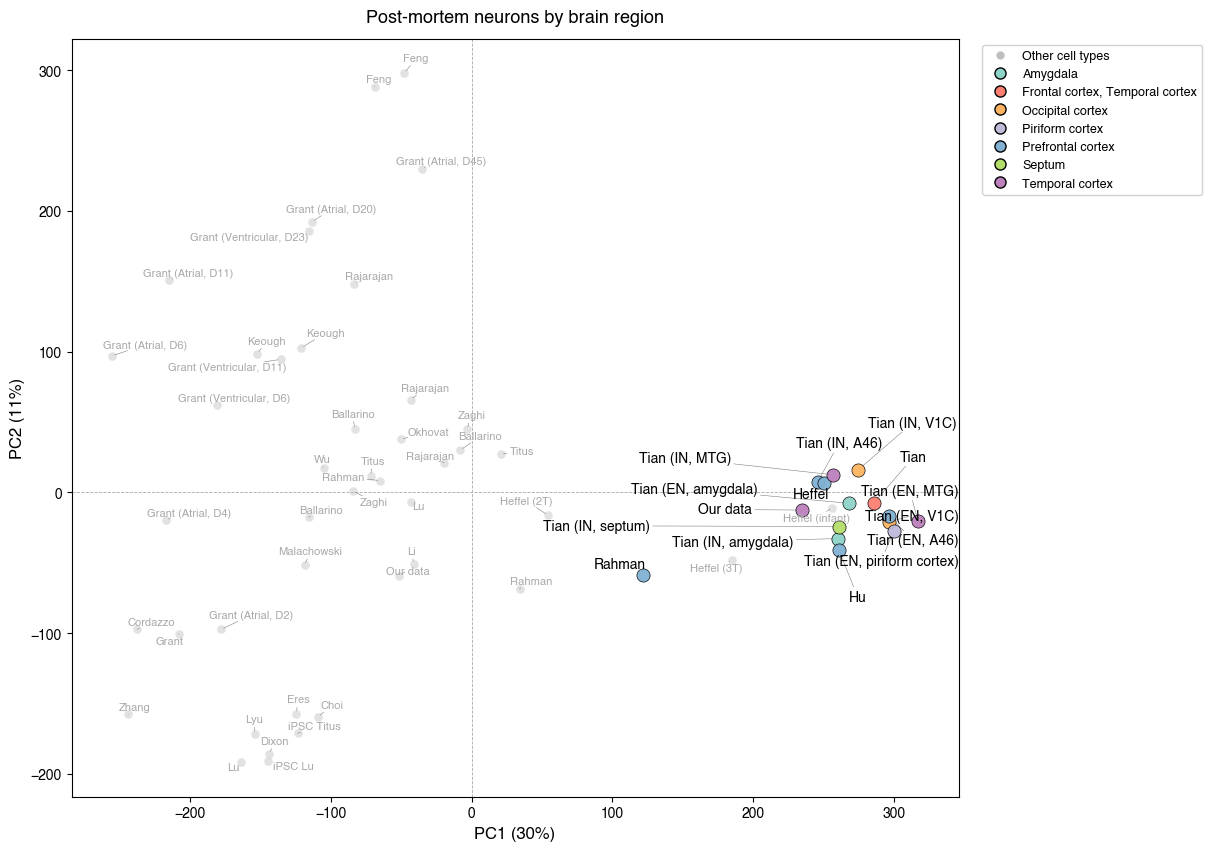

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


Saved → ./pca_postmortem_neurons_types.pdf
Saved → ./pca_postmortem_neurons_types.svg


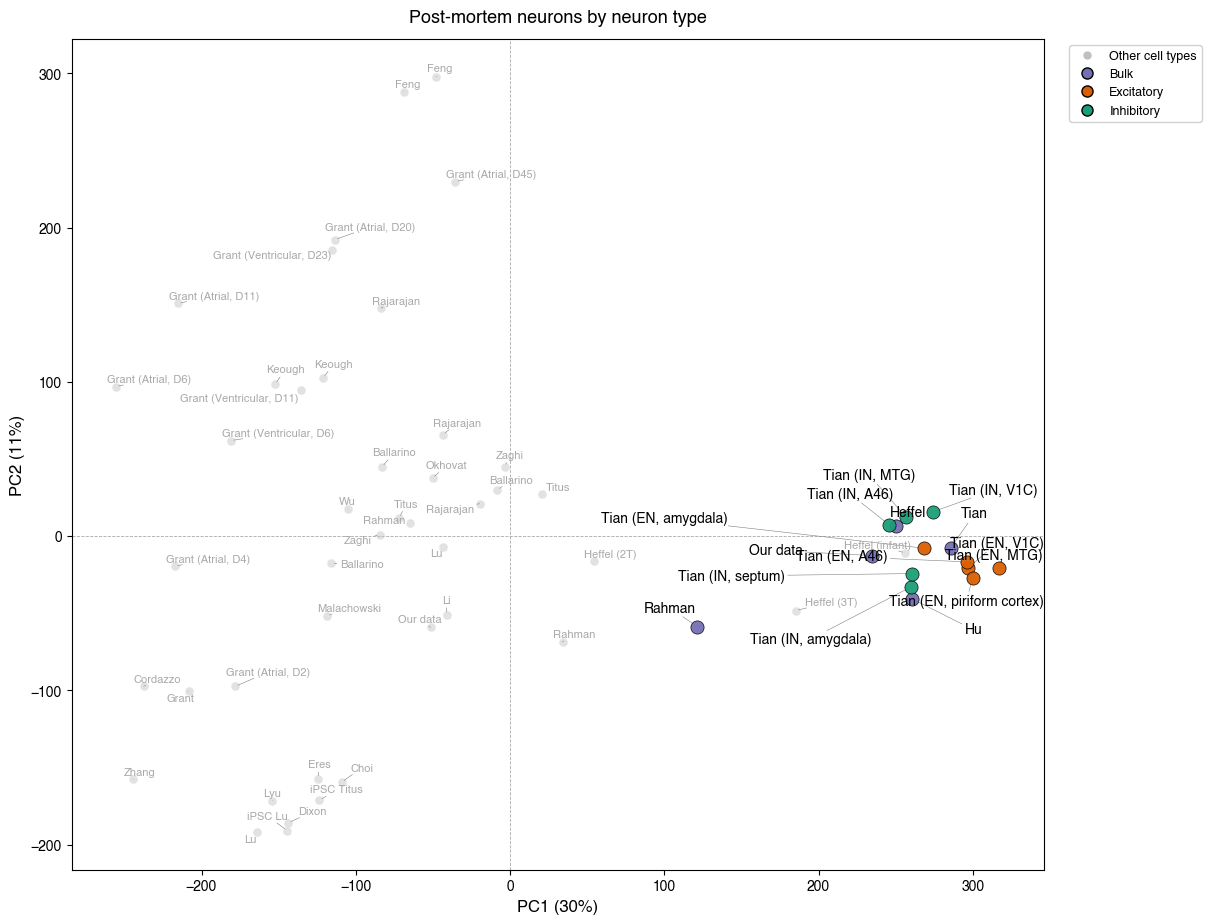

In [73]:
plt.rcParams["svg.fonttype"] = "none"

# Set font to Helvetica for consistent styling
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
plt.rcParams["pdf.fonttype"] = 42  # TrueType fonts in PDF

# ──────────────────────────────────────────────────────────────────────────────
# 1. CONFIGURATION
# ──────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR = "."  # change to desired output folder

PC1_VAR = 30  # % variance explained
PC2_VAR = 11

GREY = "#bfbfbf"
MISSING_COLOR = "#2b2b2b"  # dark charcoal for missing metadata
HIGHLIGHT_GROUP = "Post-mortem neurons"

# Categorical palettes – scientific, colorblind-friendly
# Brain region palette (7 colors from ColorBrewer Set2)
BRAIN_REGION_PALETTE = {
    "Amygdala":                        "#8dd3c7",  # light teal
    "Frontal cortex, Temporal cortex": "#fb8072",  # salmon
    "Occipital cortex":                "#fdb462",  # light orange
    "Piriform cortex":                 "#bebada",  # light purple
    "Prefrontal cortex":               "#80b1d3",  # light blue
    "Septum":                          "#b3de69",  # yellow-green
    "Temporal cortex":                 "#bc80bd",  # medium purple
}

# Neurons types palette (3 colors from ColorBrewer Dark2)
NEURONS_TYPES_PALETTE = {
    "Bulk":        "#7570b3",  # muted purple
    "Excitatory":  "#d95f02",  # orange
    "Inhibitory":  "#1b9e77",  # teal
}

FIGSIZE = (12, 12)  # Square aspect ratio
DOT_SIZE_BG = 40
DOT_SIZE_FG = 90
ALPHA_BG = 0.45
ALPHA_FG = 0.95
LABEL_FONTSIZE_BG = 8
LABEL_FONTSIZE_FG = 10

# ──────────────────────────────────────────────────────────────────────────────
# 2. DATA LOADING & PREPARATION
# ──────────────────────────────────────────────────────────────────────────────


def load_data(data_path: str, metadata_path: str) -> pd.DataFrame:
    """Load PCA data and merge with post-mortem neuron metadata."""
    df = pd.read_csv(data_path, sep="\t")
    df["group"] = df["Group"]
    df["PC1"] = pd.to_numeric(df["PC1"], errors="coerce")
    df["PC2"] = pd.to_numeric(df["PC2"], errors="coerce")
    if "sample_simple" not in df.columns:
        df["sample_simple"] = df["Sample"]

    # Metadata - merge on exact sample_simple match
    meta = pd.read_csv(metadata_path)
    # Strip whitespace from sample_simple in both dataframes
    df["sample_simple"] = df["sample_simple"].astype(str).str.strip()
    meta["sample_simple"] = meta["sample_simple"].astype(str).str.strip()
    
    meta = meta[["sample_simple", "Brain region", "Neurons types"]]
    df = df.merge(meta, on="sample_simple", how="left")

    # Strip whitespace from metadata string columns
    for col in ["Brain region", "Neurons types"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace({"nan": np.nan, "": np.nan})

    return df


# ──────────────────────────────────────────────────────────────────────────────
# 3. PLOTTING HELPERS
# ──────────────────────────────────────────────────────────────────────────────


def _add_labels(ax, df_subset, fontsize, color="dimgrey"):
    """Add sample_simple text labels and return the Text objects."""
    texts = []
    for _, row in df_subset.iterrows():
        t = ax.text(
            row["PC1"], row["PC2"],
            str(row["sample_simple"]),
            fontsize=fontsize,
            color=color,
            ha="right", va="bottom",
            zorder=5,
        )
        texts.append(t)
    return texts


def _base_ax(df: pd.DataFrame) -> tuple:
    """Create figure, plot grey background dots with labels, return (fig, ax, bg_texts)."""
    fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

    bg = df[df["group"] != HIGHLIGHT_GROUP]
    ax.scatter(
        bg["PC1"],
        bg["PC2"],
        c=GREY,
        s=DOT_SIZE_BG,
        alpha=ALPHA_BG,
        edgecolors="white",
        linewidths=0.3,
        zorder=1,
        label="_nolegend_",
    )

    bg_texts = _add_labels(ax, bg, LABEL_FONTSIZE_BG, color="#aaaaaa")

    ax.axhline(0, color="darkgrey", ls="--", lw=0.6, zorder=0)
    ax.axvline(0, color="darkgrey", ls="--", lw=0.6, zorder=0)
    ax.set_xlabel(f"PC1 ({PC1_VAR}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({PC2_VAR}%)", fontsize=12)
    ax.tick_params(labelsize=10)
    ax.set_aspect('equal', adjustable='box')  # Make plot area square
    return fig, ax, bg_texts


def _finish(fig, ax, title: str, fname: str, legend_handles=None, all_texts=None):
    """Add title, legend, adjust labels, save and show."""
    ax.set_title(title, fontsize=13, pad=12)
    if legend_handles is not None:
        ax.legend(
            handles=legend_handles,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            fontsize=9,
            frameon=True,
            framealpha=0.9,
            title_fontsize=10,
        )
    if all_texts:
        adjust_text(
            all_texts, ax=ax,
            arrowprops=dict(arrowstyle="-", color="grey", lw=0.4),
            expand=(1.2, 1.4),
            force_text=(0.3, 0.5),
            only_move={"points": "y", "texts": "xy"},
        )
    # Don't use tight_layout - constrained_layout is already set in subplots
    
    # Save both PDF and SVG formats
    base_name = fname.rsplit(".", 1)[0]  # Remove extension
    pdf_out = f"{OUTPUT_DIR}/{base_name}.pdf"
    svg_out = f"{OUTPUT_DIR}/{base_name}.svg"
    
    # Don't use bbox_inches='tight' as it can distort the square aspect ratio
    fig.savefig(pdf_out, dpi=300)
    fig.savefig(svg_out)
    
    print(f"Saved → {pdf_out}")
    print(f"Saved → {svg_out}")
    plt.show()


def _get_palette(series: pd.Series, predefined: dict) -> dict:
    """Return a palette dict covering every unique non-null value in *series*.

    Uses *predefined* colours where available; assigns new colours from tab10
    for any unseen categories.
    """
    unique_vals = sorted(series.dropna().unique(), key=str)
    palette = {}
    extra_idx = 0
    extra_colors = plt.cm.tab10.colors
    for v in unique_vals:
        if v in predefined:
            palette[v] = predefined[v]
        else:
            palette[v] = mcolors.to_hex(extra_colors[extra_idx % len(extra_colors)])
            extra_idx += 1
    return palette


# ──────────────────────────────────────────────────────────────────────────────
# 4. FIGURE FUNCTIONS
# ──────────────────────────────────────────────────────────────────────────────


def plot_categorical(
    df: pd.DataFrame,
    col: str,
    predefined_palette: dict,
    title: str,
    fname: str,
):
    """Generic categorical colouring for post-mortem neurons."""
    fig, ax, bg_texts = _base_ax(df)
    fg = df[df["group"] == HIGHLIGHT_GROUP].copy()

    palette = _get_palette(fg[col], predefined_palette)

    has_val = fg[col].notna()
    fg_miss = fg[~has_val]
    fg_good = fg[has_val]

    # Plot each category
    for cat, colour in palette.items():
        sub = fg_good[fg_good[col] == cat]
        if sub.empty:
            continue
        ax.scatter(
            sub["PC1"],
            sub["PC2"],
            c=colour,
            s=DOT_SIZE_FG,
            alpha=ALPHA_FG,
            edgecolors="k",
            linewidths=0.5,
            zorder=3,
        )

    # Missing
    if not fg_miss.empty:
        ax.scatter(
            fg_miss["PC1"],
            fg_miss["PC2"],
            c=MISSING_COLOR,
            s=DOT_SIZE_FG,
            alpha=ALPHA_FG,
            edgecolors="k",
            linewidths=0.5,
            zorder=3,
            marker="X",
        )

    # Foreground labels
    fg_texts = _add_labels(ax, fg, LABEL_FONTSIZE_FG, color="black")

    # Legend
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=GREY,
               markersize=7, label="Other cell types", markeredgecolor="white")
    ]
    for cat, colour in palette.items():
        handles.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor=colour,
                   markersize=8, label=str(cat), markeredgecolor="k")
        )
    if not fg_miss.empty:
        handles.append(
            Line2D([0], [0], marker="X", color="w", markerfacecolor=MISSING_COLOR,
                   markersize=8, label="Missing", markeredgecolor="k")
        )
    _finish(fig, ax, title, fname, handles, all_texts=bg_texts + fg_texts)



def main():
    df = load_data(DATA_PATH, METADATA_PATH_POST_MORTEM)

    # Fig 1 – Brain region (categorical)
    plot_categorical(
        df,
        col="Brain region",
        predefined_palette=BRAIN_REGION_PALETTE,
        title="Post-mortem neurons by brain region",
        fname="pca_postmortem_brain_region.pdf",
    )

    # Fig 2 – Neurons types (categorical)
    plot_categorical(
        df,
        col="Neurons types",
        predefined_palette=NEURONS_TYPES_PALETTE,
        title="Post-mortem neurons by neuron type",
        fname="pca_postmortem_neurons_types.pdf",
    )


if __name__ == "__main__":
    main()
